# Expérience 1 — popularité sur fenêtre glissante

**Question** : sur quelle durée faut-il compter les clics pour recommander « ce
qu'on lit en ce moment » ?

Le projet utilise aujourd'hui la popularité calculée sur **tout** l'historique.
Sur un flux d'actualité, c'est probablement une erreur : un article très lu il y a
dix jours n'intéresse plus personne.

Cette méthode ne personnalise rien — elle sert la même liste à tous. Elle est donc
la **référence à battre** : toute méthode plus complexe doit faire mieux.

## Protocole commun

Identique dans tous les notebooks d'expérimentation, sinon les chiffres ne sont pas
comparables :

- **découpage temporel 60 / 20 / 20** sur `click_timestamp` ;
- artefacts construits sur la **seule** période d'entraînement (`models_split/`) ;
- réglage sur la **validation** ; la période de test reste intacte jusqu'à la mesure
  finale (notebook 07) ;
- lecteurs évalués : connus à l'entraînement **et** actifs pendant la période
  d'évaluation ;
- métriques : HitRate@5, Recall@5, couverture, personnalisation.

> Prérequis : `python -m src.evaluate --data-dir data/news-portal-user --out-dir models_split`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')

from src import experiments as xp
from src.recommender import Recommender

DATA = Path('..') / 'data' / 'news-portal-user'
MODELS = Path('..') / 'models_split'

train, val, test = xp.load_split(DATA)
reco = Recommender(MODELS)
users, cible = xp.eval_users(reco, val, max_users=2000)
print(f'{len(users):,} lecteurs évalués sur la période de validation')

[clicks] 1 fichier(s) vide(s) ignoré(s) : clicks_hour_100.csv


[split] entraînement 1,792,908 | validation 597,636 | test 597,637
[split] bornes temporelles : t60=1507602953792 t80=1507843212579


2,000 lecteurs évalués sur la période de validation


## Grille de fenêtres

Pour chaque durée, on compte les clics des dernières heures de la période
d'entraînement et on prend les 5 articles les plus lus.

In [2]:
FENETRES = [1, 3, 6, 12, 24, 48, 72, 240]

resultats = {}
tailles = {}
for heures in FENETRES:
    pool = xp.recent_pool(train, heures)
    tailles[heures] = pool.size
    resultats[f'{heures} h'] = xp.make_popularity(pool)

tableau = xp.compare(resultats, users, cible, n_articles=reco.n_articles)
tableau.insert(0, 'articles dans la fenêtre', [tailles[h] for h in FENETRES])
tableau

,articles dans la fenêtre,HitRate@5,Recall@5,couverture %,personnalisation %
configuration,,,,,
1 h,791,0.2170,0.0486,0.001,0.0
3 h,1669,0.2150,0.0462,0.001,0.0
6 h,2657,0.1320,0.0222,0.001,0.0
12 h,5086,0.1205,0.0195,0.001,0.0
24 h,6777,0.1035,0.0157,0.001,0.0
48 h,9133,0.1020,0.0155,0.001,0.0
72 h,11244,0.1020,0.0155,0.001,0.0
240 h,29118,0.0010,0.0001,0.001,0.0


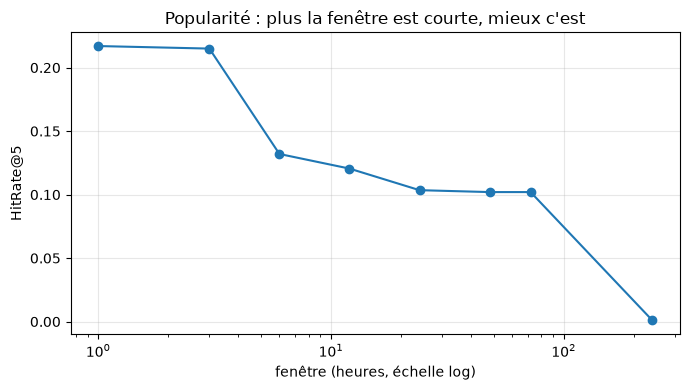

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(FENETRES, tableau['HitRate@5'].to_numpy(), marker='o')
ax.set_xscale('log')
ax.set_xlabel("fenêtre (heures, échelle log)")
ax.set_ylabel('HitRate@5')
ax.set_title("Popularité : plus la fenêtre est courte, mieux c'est")
ax.grid(alpha=.3)
plt.tight_layout()

## Lecture

Le résultat est le fait le plus important de toute l'évaluation : **la durée de la
fenêtre compte davantage que le choix de l'algorithme**. La même méthode, avec un
comptage sur quelques heures au lieu de tout l'historique, change d'un ordre de
grandeur.

Explication : 48 % des articles lus pendant la période d'évaluation n'avaient
**jamais** été cliqués pendant l'entraînement. Ils viennent d'être publiés. Une
fenêtre courte capte cette vague, une fenêtre longue la noie dans l'historique.

Conséquence pour le produit : `popular_articles.npy` et `article_stars.npy`
devraient être recalculés sur fenêtre glissante, comme prévu en §4.c de
`docs/architecture.md` — ce qui n'est pas encore fait.

La meilleure fenêtre trouvée ici sert de vivier de candidats aux autres notebooks.